# Global landscape features

Illustrates MOLA's **global** landscape features (paper §4.1.1, Table 1) — the one class that does not depend on the neighbourhood graph. Each section below pairs a feature's definition with a small, real, *executed* example built on `mola`'s own code, not hand-typed numbers: if the implementation ever changes, re-running this notebook is the check.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook, only `dist_x_avg` exists.

## `dist_x_avg` — average distance among solutions in variable space

> "the average and maximum distance among sampled solutions in the variable space" (§4.1.1)

Computed as the mean Euclidean distance over every pair of sampled solutions in **decision** space, then max-min normalized against that *same sample's own* pairwise-distance range (Design decisions, "Normalization reference") — never against the search-space bounds, and never recomputed over a subset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import pairwise_distance_stats
from mola.features import dist_x_avg
from mola.normalization import Normalizer

# Three 2-D toy samples, deliberately built to have very different shapes:
rng = np.random.default_rng(seed=0)
samples = {
    "spread": rng.uniform(low=0.0, high=10.0, size=(15, 2)),
    "clustered": rng.normal(loc=(5.0, 5.0), scale=0.3, size=(15, 2)),
}
cluster_core = rng.normal(loc=(5.0, 5.0), scale=0.3, size=(14, 2))
samples["with_outlier"] = np.vstack([cluster_core, [[20.0, 20.0]]])

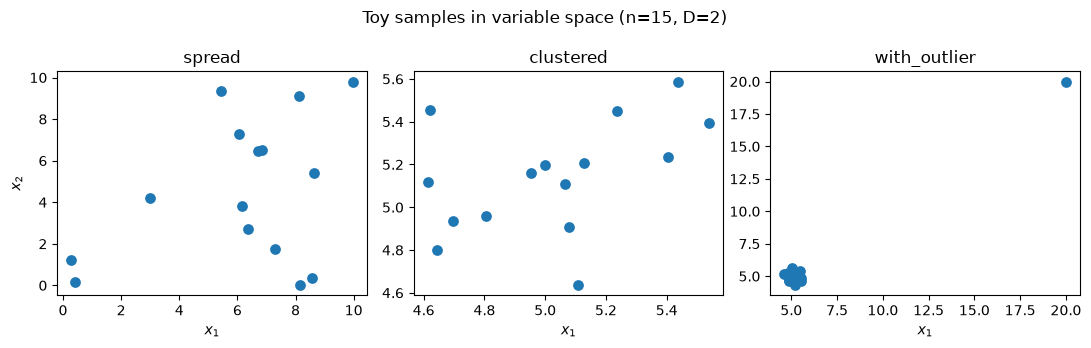

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=False, sharey=False)
for ax, (label, points) in zip(axes, samples.items(), strict=True):
    ax.scatter(points[:, 0], points[:, 1], s=45)
    ax.set_title(label)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
fig.suptitle("Toy samples in variable space (n=15, D=2)")
fig.tight_layout()
plt.show()

In [3]:
for label, points in samples.items():
    stats = pairwise_distance_stats(points)
    normalizer = Normalizer(minimum=stats.minimum, maximum=stats.maximum)
    value = dist_x_avg(points, normalizer)
    print(
        f"{label:13s} raw range=[{stats.minimum:6.3f}, {stats.maximum:6.3f}]"
        f"  raw mean={stats.mean:6.3f}   dist_x_avg={value:.3f}"
    )

spread        raw range=[ 0.153, 13.580]  raw mean= 5.665   dist_x_avg=0.411
clustered     raw range=[ 0.058,  1.117]  raw mean= 0.511   dist_x_avg=0.428
with_outlier  raw range=[ 0.029, 21.555]  raw mean= 3.338   dist_x_avg=0.154


**Reading the numbers above.** `Normalizer` is always fixed to *this sample's own* pairwise-distance range, never a global or search-space bound — so `dist_x_avg` is not a cross-sample-comparable measure of "how spread out" a sample is. `spread` and `clustered` land on nearly the same value despite an order-of-magnitude difference in absolute scale: both have a roughly uniform *shape* of pairwise distances relative to their own range. `with_outlier` scores far lower: most pairs sit close together inside the tight cluster, and only the few pairs touching the outlier stretch the range, pulling the *mean* down toward the *minimum*. `dist_x_avg` captures that shape, not the absolute scale.

## `dist_x_max` — maximum distance among solutions in variable space

> "the average and maximum distance among sampled solutions in the variable space" (§4.1.1)

The counterpart to `dist_x_avg`, over the same pairwise distances — but reported **raw**, never normalized (every `*_MAX` feature stays raw). Reusing the three samples above makes the contrast with `dist_x_avg` explicit: the *raw* maximum differs by an order of magnitude between `spread` and `clustered` — exactly the difference `dist_x_avg`'s per-sample normalization hides.

In [4]:
from mola.features import dist_x_max

for label, points in samples.items():
    value = dist_x_max(points)
    print(f"{label:13s} dist_x_max={value:.3f}")

spread        dist_x_max=13.580
clustered     dist_x_max=1.117
with_outlier  dist_x_max=21.555


## `dist_f_max` — maximum distance among solutions in objective space

> "the average and maximum distance among sampled solutions in the objective space" (§4.1.1)

Same statistic as `dist_x_max`, computed over **objective** vectors instead of decision vectors — `pairwise_distance_stats` doesn't care which space it's given, only that it's handed points. Also raw, never normalized. The toy front below deliberately includes one dominated solution (`F`): `dist_f_max` runs over the whole sample, not just the non-dominated subset — that restriction is what `dist_x_nd_max` (not yet implemented) will add.

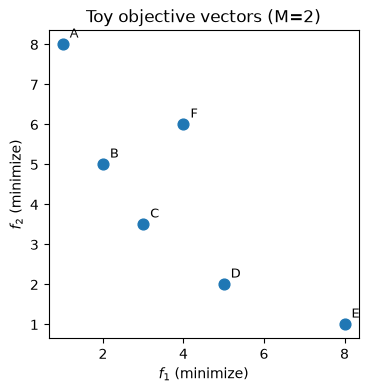

dist_f_max = 9.899


In [5]:
from mola.features import dist_f_max

objectives = np.array(
    [
        [1.0, 8.0],
        [2.0, 5.0],
        [3.0, 3.5],
        [5.0, 2.0],
        [8.0, 1.0],
        [4.0, 6.0],
    ]
)
labels = list("ABCDEF")

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(objectives[:, 0], objectives[:, 1], s=60)
for label, (f1, f2) in zip(labels, objectives, strict=True):
    ax.annotate(label, (f1, f2), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("$f_1$ (minimize)")
ax.set_ylabel("$f_2$ (minimize)")
ax.set_title("Toy objective vectors (M=2)")
plt.show()

print(f"dist_f_max = {dist_f_max(objectives):.3f}")